In [1]:
import gc
import yaml
import torch
import pandas as pd
import seaborn as sns

from scripts.llama_child import Llama
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from utils.misc_utils import *

from sklearn.metrics import davies_bouldin_score
from peft import get_peft_model

/mfs1/u/jayje/condaenvs/multi_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!export OMP_NUM_THREADS=1

In [3]:
!nvidia-smi

Thu May  1 17:10:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:40:00.0 Off |                    0 |
| N/A   28C    P0             68W /  700W |       1MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
get_mem_usage_stats("")

State  Device 0: total mem 79.65, free mem 79.10
State  Total virtual memory available 944 GB | Virtual memory % used: 6.0% | CPU memory % used: 0.0%


In [6]:
device='cuda'

In [7]:
cls_params = {
                        "model_name": "meta-llama/Llama-3.1-8B-Instruct",
                        "dataset_name": "/h/371/jayje/ft-intrinsic-dim/data/object_counting.json",
                        "data_size":None,
                        "task": "object_counting",
                        "use_quantized":False,
                        "use_peft":True,
                        "peft_method":"lora",
                        "r":64,
                        "density":None,
                        "seed":123
                    }

model_cls = Llama(**cls_params)

In [8]:
model, tokenizer = model_cls.get_model_and_tokenizer(use_flash_attention=True, on_vector=False)

using args:  {'pretrained_model_name_or_path': 'meta-llama/Llama-3.1-8B-Instruct', 'attn_implementation': 'flash_attention_2', 'torch_dtype': torch.bfloat16}


You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  5.80it/s]


Padding tokenizer pad token to 128009


In [9]:
# peft_config = model_cls.get_peft_config()
# model = get_peft_model(model, peft_config) 
## jje: this is weird because now we're doing just activations, not gradients

In [10]:
# model.to("cpu")
# del model

# gc.collect()
# torch.cuda.empty_cache()
# !nvidia-smi

In [11]:
model.eval()
model.to("cuda")

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaFlashAttention2(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    

In [12]:
def get_activation(name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            activations[name] = output[0].detach().cpu() # could choose the first index instead
        else:
            activations[name] = output.detach().cpu()
            
    return hook

# Register hooks on transformer blocks (e.g., the MLP layer of each block)
for i, block in enumerate(model.model.layers):  # assuming `model.model.layers` is the block list
    block.mlp.register_forward_hook(get_activation(f"mlp_{i}"))
    block.self_attn.register_forward_hook(get_activation(f"self_attn_{i}"))

In [13]:
def batch_sample(data, split, example_num):

    ls = []
    for i in example_num:
        ls.append(data[split][int(i)]['text'])

    print(example_num)
    batched_input = tokenizer(ls,
                              padding=True,
                              return_tensors="pt",
                              add_special_tokens=False).to(device)

    return batched_input

In [14]:
# Load the task example number, labels (proba), cosine, and AUC to create the default data 
df_proba = load_proba_stats(path="../results/per_sample_result/model_proba_per_sample_2500_v2.json")

In [15]:
df_cos = load_cosine_stats(path="../results/per_sample_result/cosine_similarity_metrics_32_v2_conf_dec0.json")

In [16]:
df_auc = load_auc(path="../results/auc_res/auc_normalized_log_by_task_2500.json",
                  tasks_to_exclude=['typescript_chunks'])
df_ = pd.merge(df_proba,
         df_cos,
         on = ['task','example_num'],
         how='inner'
         )
df = pd.merge(df_,
         df_auc,
         on = ['task'],
         how='inner'
         )

df['target_concat'] = df.apply(lambda x: "".join([str(i) for i in x['target']]), axis=1)

In [17]:
df.head()

,task,example_num,target_proba,model_pred_proba,avg_error,avg_confidence,target,model_pred,cos_sim,cos_sim_log,auc,avg_slope,max_acc,min_acc,target_concat
0,ade_corpus_v2_classification,1,0.46878,0.531198,0.53122,0.531198,[15],[16],0.677635,0.746429,0.620973,0.053967,0.959184,0.472789,15
1,ade_corpus_v2_classification,10,0.499998,0.499998,0.500002,0.499998,[15],[15],0.697221,0.763174,0.620973,0.053967,0.959184,0.472789,15
2,ade_corpus_v2_classification,48,0.407322,0.59265,0.592678,0.59265,[15],[16],0.717460,0.780277,0.620973,0.053967,0.959184,0.472789,15
3,ade_corpus_v2_classification,90,0.407323,0.592651,0.592677,0.592651,[15],[16],0.685587,0.753251,0.620973,0.053967,0.959184,0.472789,15
4,ade_corpus_v2_classification,91,0.468786,0.531204,0.531214,0.531204,[15],[16],0.620564,0.696496,0.620973,0.053967,0.959184,0.472789,15


In [18]:
tsne = TSNE(n_components=2, perplexity=5)

In [19]:
!nvidia-smi

Thu May  1 17:11:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:40:00.0 Off |                    0 |
| N/A   32C    P0            115W /  700W |   15972MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [20]:
task_dbindex={}
task_tsne={}
task_cos_mean={}
with open('../prompts/prompts_by_task_modified.yaml','r') as f:
        prompt = yaml.safe_load(f)
tasks_to_exclude = ['cardiffnlp/tweet_topic_single','pacovaldez/stackoverflow-questions', 'nvidia/OpenMathInstruct-2','allenai/ai2_arc',
                        'maveriq/bigbenchhard', 'SahandNZ/cryptonews-articles-with-price-momentum-labels',
                        'saier/unarXive_imrad_clf', 'allenai/qasc', 'allenai/sciq','jpwahle/machine-paraphrase-dataset',
                        'masakhane/masakhanews', '/h/371/jayje/ft-intrinsic-dim/data/elementary_math_qa_question_only.json',
                        'openai/gsm8k','/h/371/jayje/ft-intrinsic-dim/data/qa_wikidata.json', '/h/371/jayje/ft-intrinsic-dim/data/disfl_qa.json',
                        '/h/371/jayje/ft-intrinsic-dim/data/polish_sequence_labeling.json','ehovy/race'
                        ]
datasets_to_check = set(list(prompt.keys())) - set(tasks_to_exclude)

for k in datasets_to_check:
        print(k)
        gc.collect()
        torch.cuda.empty_cache()
        
        dataset_name = k
        tasks = list(prompt[k].keys())
        
        for task in tasks:
            task_activations = {}
            key = task.lower() if task is not None else dataset_name.split("/")[-1].replace('-','_').lower()

            if key not in df['task'].unique():
                print(f"{key} not in df")
                continue

       #      if key in ['temporal_sequences', 'toxicchat0124', 'ade_corpus_v2_classification',
       # 'hyperbaton', 'tokenized', 'mnist_ascii', 'sports_understanding',
       # 'fig_qa', 'boolq', 'rte', 'wic', 'unit_conversion_si_conversion',
       # 'anli', 'commonsense_qa', 'mnli', 'mrpc', 'qnli', 'qqp', 'sst2',
       # 'circa', 'tracking_shuffled_objects',
       # 'formal_fallacies_syllogisms_negation']+['intersect_geometry', 'overruling', 'reasoning_about_colored_objects',
       # 'object_counting', 'mmlu','banking77','high']: # added the race data because it can't fit?
       #          print(f"{key} already processed")
       #          continue
            
            model_cls.dataset_name = dataset_name
            model_cls.task = task
            model_cls.task_prompt = model_cls.load_task_prompt()
            
            data = model_cls.get_data(tokenizer=tokenizer, max_seq_len=2048, filter_long_seq=False, load_from_cache_file = True)
            data['train'] = data['train'].shuffle(seed=123)
            if data['train'].num_rows > 2500:
                data['train'] = data['train'].select(range(2500))
            
            c=0
            # Pass 32 (* 4) data points and get the activations (for each layer) stacked for these examples
            accumulate_steps = 4
            batch_size = 16
            example_nums = df[df['task']==key]['example_num'].values[: (accumulate_steps) * batch_size]
            mean_cosine = df[df['task']==key]['cos_sim'].values[: (accumulate_steps) * batch_size].mean()
            mean_cosine_log = df[df['task']==key]['cos_sim_log'].values[: (accumulate_steps) * batch_size].mean()
            labels = df[df['task']==key]['target_concat'].values[: (accumulate_steps) * batch_size]
            
            while c < accumulate_steps:
                print(f"accumulation step {c}...")
                batched_input = batch_sample(data, 'train', example_nums[c*batch_size : (c+1)*batch_size])
                
                get_mem_usage_stats(f"memory before passing")
                activations = {}
                with torch.no_grad():
                    _ = model(**batched_input)

                get_mem_usage_stats(f"memory after passing")
                # collect activations for this task
                for module in activations:
                    if module not in task_activations:
                        task_activations[module] = []
                    task_activations[module].append(activations[module].to(torch.float32))
                c += 1

                get_mem_usage_stats(f"memory after saving to task_activations")

            # calculate ...
            task_dbindex[key] = {}
            task_cos_mean[key] = {}
            # task_tsne[key] = {}
            task_cos_mean[key]['cos_sim_mean'] = mean_cosine
            task_cos_mean[key]['cos_sim_log_mean'] = mean_cosine_log
            for module in task_activations:
                # DB index for each layer
                task_dbindex[key][module] = []
                # task_tsne[key][module] = []
                for i in range(len(task_activations[module])):
                    stacked_ac = task_activations[module][i].to(torch.float32).reshape(batch_size,-1)
                    subset_labels = labels[i*batch_size:(i+1)*batch_size]

                    if len(set(subset_labels)) == stacked_ac.shape[0] or len(set(subset_labels)) == 1:
                        print(f"Skipping because label count {len(set(subset_labels))}")
                        continue
                    score = davies_bouldin_score(stacked_ac, labels[i*batch_size:(i+1)*batch_size])
                    task_dbindex[key][module].append(score)
            
            del activations
            del task_activations

super_glue


Map: 100%|██████████| 943/943 [00:00<00:00, 7725.51 examples/s]


Data train size : 8484 Validation: 1696 Test: 943
accumulation step 0...
[  3   9  23  26  29  50  65  71  74  75  86  99 131 135 151 157]
State memory before passing Device 0: total mem 79.65, free mem 63.50
State memory before passing Total virtual memory available 944 GB | Virtual memory % used: 6.0% | CPU memory % used: 1.0%


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


State memory after passing Device 0: total mem 79.65, free mem 58.34
State memory after passing Total virtual memory available 941 GB | Virtual memory % used: 6.0% | CPU memory % used: 1.0%
State memory after saving to task_activations Device 0: total mem 79.65, free mem 58.34
State memory after saving to task_activations Total virtual memory available 936 GB | Virtual memory % used: 7.0% | CPU memory % used: 2.0%
accumulation step 1...
[158 159 162 163 169 180 192 200 203 207 243 255 292 301 314 323]
State memory before passing Device 0: total mem 79.65, free mem 58.34
State memory before passing Total virtual memory available 936 GB | Virtual memory % used: 7.0% | CPU memory % used: 3.0%
State memory after passing Device 0: total mem 79.65, free mem 53.79
State memory after passing Total virtual memory available 935 GB | Virtual memory % used: 7.0% | CPU memory % used: 1.0%
State memory after saving to task_activations Device 0: total mem 79.65, free mem 53.79
State memory after savi

In [21]:
tmp = pd.DataFrame(task_dbindex)

In [22]:
tmp.columns # already processed

Index(['boolq', 'rte', 'wic', 'temporal_sequences', 'web_of_lies',
       'tracking_shuffled_objects', 'circa', 'object_counting',
       'ade_corpus_v2_classification', 'overruling', 'medmcqa',
       'commonsense_qa', 'unit_conversion_si_conversion', 'mnist_ascii',
       'fig_qa', 'intersect_geometry', 'formal_fallacies_syllogisms_negation',
       'mnli', 'mrpc', 'qnli', 'qqp', 'sst2', 'hyperbaton', 'tokenized',
       'banking77', 'sports_understanding', 'reasoning_about_colored_objects',
       'toxicchat0124', 'anli', 'mmlu'],
      dtype='object')

In [23]:
tmp

,boolq,rte,wic,temporal_sequences,web_of_lies,tracking_shuffled_objects,circa,object_counting,ade_corpus_v2_classification,overruling,...,qqp,sst2,hyperbaton,tokenized,banking77,sports_understanding,reasoning_about_colored_objects,toxicchat0124,anli,mmlu
self_attn_0,"[2.1820640573974077, 2.7664611383392934, 3.675...","[1.0598414391779776, 1.1791183689812021, 1.191...","[2.9099932680023337, 3.3391998581742453, 4.005...","[2.3646330009931336, 2.7607021944719996, 2.742...","[2.5198556960447327, 3.353880643622113, 4.4209...","[2.335019445430103, 1.4857743770918987, 2.4871...","[3.3305289901972044, 3.439843358326184, 3.4853...","[1.4520067331085684, 1.8393755652278798, 1.082...",[0.915117054060452],"[3.007439961558502, 2.6621218243102343, 1.1032...",...,"[3.301153284177658, 3.031453345722198, 3.58596...","[3.3563467750318594, 2.919714702430683, 4.4764...","[2.507173897667216, 3.308492800819622, 0.79114...","[2.313873271585535, 2.5948166734261537, 2.4462...","[0.8734533993491125, 0.8411832465981228, 1.016...","[2.2049176431596904, 3.6886565338308333, 2.180...","[0.9703998214668986, 1.4058070640822835, 1.207...","[2.704679758319843, 2.9791944540672666, 0.9440...","[3.0014246103352296, 2.6352815466145754, 3.139...","[2.518102483525328, 2.561125073666802, 2.41963..."
mlp_0,"[2.967786634665519, 3.2707682916200977, 3.6168...","[1.0004427879519113, 1.116634872207483, 1.1976...","[3.0384999049790715, 3.4069922432225956, 3.700...","[2.3954169101932132, 2.573666810449411, 2.5610...","[3.011160505903116, 3.387814911991771, 3.85938...","[2.31162368927766, 1.5412687405998489, 2.33773...","[3.404677695472327, 3.5531702684610407, 3.4061...","[1.429084425559818, 1.7717279172147102, 1.0801...",[0.9672317733598426],"[2.9025867217744685, 2.7991745650938733, 0.985...",...,"[3.8567265384885117, 3.1175664869221493, 3.951...","[3.450529121746546, 3.475397842175632, 4.20177...","[2.553858392599128, 3.1642073158987767, 0.9070...","[2.1624381726883093, 2.4634314200049205, 2.302...","[0.9523760177335052, 0.8931994589404725, 1.001...","[2.5433273467938133, 3.6706650767507645, 2.202...","[0.9556870097180409, 1.3444526360961, 1.190858...","[2.208019622299994, 3.076916605535891, 0.88742...","[2.966293041126054, 2.778821070222394, 3.03873...","[2.4517185285869707, 2.516515677852543, 2.3438..."
self_attn_1,"[2.859528296928371, 3.1860964919759205, 3.5994...","[0.9773513698638183, 1.1648331104158527, 1.180...","[2.916963023306225, 3.3922207917911567, 3.7870...","[2.3932612450667756, 2.648144111762484, 2.7408...","[2.7900625596877333, 3.4424653603888498, 3.889...","[2.361507199158976, 1.5206817253907234, 2.4167...","[3.377235312920838, 3.3991307073090886, 3.5980...","[1.411415878935002, 1.7716883325559152, 1.0906...",[0.949967176088454],"[2.864838004126767, 2.724654833358904, 0.97791...",...,"[3.6752924551674226, 3.0910284972984887, 3.803...","[3.3844214318132964, 3.2085205690154894, 3.804...","[2.640337633296411, 3.2977760266074476, 0.8894...","[2.2061442975904613, 2.4936100804173735, 2.334...","[0.8787250861262358, 0.8553371705226387, 0.982...","[2.499032012187027, 3.431102711938647, 2.13172...","[0.9907941274446723, 1.4176071695387977, 1.198...","[2.2528089867305567, 3.024229050668369, 0.9037...","[2.9138668539382273, 2.73457444383212, 3.04261...","[2.436564485543877, 2.493018368829205, 2.33214..."
mlp_1,"[2.658671578035528, 3.107215069581096, 3.61295...","[0.9909980165934609, 1.176678534026284, 1.2221...","[3.0506507330473474, 3.417863851528515, 3.7293...","[2.369380397568818, 2.6096046676117735, 2.6279...","[2.8836497393548304, 3.4416978944327647, 3.957...","[2.2860069525383326, 1.541488845694872, 2.3425...","[3.449373372525638, 3.5058119955083704, 3.5386...","[1.4442745547386162, 1.7766386041695672, 1.080...",[0.9236610586872678],"[2.929350291547621, 2.704462330314565, 1.02518...",...,"[3.581452992439545, 3.0409577994232295, 3.7292...","[3.4547569673398226, 3.273418210253324, 4.0696...","[2.663396448959266, 3.1885235692929594, 0.8706...","[2.195756532364359, 2.

In [24]:
for c in tmp.columns:
    tmp[c] = tmp.apply(lambda x: np.mean(x[c]),axis=1)

In [25]:
tmp = tmp.T
tmp.head()

,self_attn_0,mlp_0,self_attn_1,mlp_1,self_attn_2,mlp_2,self_attn_3,mlp_3,self_attn_4,mlp_4,...,self_attn_27,mlp_27,self_attn_28,mlp_28,self_attn_29,mlp_29,self_attn_30,mlp_30,self_attn_31,mlp_31
boolq,3.156484,3.394740,3.352469,3.297132,3.234831,3.145690,3.372281,3.227288,3.351136,3.257740,...,3.339682,3.321497,3.346526,3.287885,3.302262,3.263397,3.294729,3.243280,3.287108,3.069413
rte,1.547294,1.511574,1.529538,1.538945,1.557998,1.550272,1.499663,1.522272,1.470885,1.503231,...,1.547457,1.518490,1.464393,1.512488,1.490171,1.512600,1.457513,1.514938,1.490319,1.535492
wic,3.376527,3.344913,3.333041,3.376978,3.358786,3.429511,3.357164,3.396567,3.317071,3.371118,...,3.291952,3.367519,3.260973,3.365104,3.273940,3.369073,3.255147,3.312488,3.267114,3.433283
temporal_sequences,2.526422,2.456416,2.516498,2.475230,2.561793,2.519524,2.559922,2.505744,2.537811,2.507134,...,2.499747,2.494792,2.496645,2.489307,2.510359,2.495588,2.528577,2.509221,2.538507,2.595316
web_of_lies,3.381645,3.492419,3.453270,3.440551,3.391396,3.401042,3.444304,3.422867,3.454069,3.430652,...,3.412743,3.464117,3.450811,3.431945,3.426549,3.433962,3.422345,3.430855,3.437798,3.411696


In [26]:
tmp_cos = pd.DataFrame(task_cos_mean).T

In [27]:
tmp_cos

,cos_sim_mean,cos_sim_log_mean
boolq,-0.005473,-0.008151
rte,0.216695,0.266400
wic,0.045742,0.037222
temporal_sequences,0.075038,0.092103
web_of_lies,0.016350,0.003086
tracking_shuffled_objects,0.023471,0.023837
circa,0.589618,0.666423
object_counting,0.322677,0.392875
ade_corpus_v2_classification,0.668762,0.715973
overruling,0.273170,0.301003


In [28]:
tmp_fin=tmp.join(
    tmp_cos
)

In [29]:
tmp_fin

,self_attn_0,mlp_0,self_attn_1,mlp_1,self_attn_2,mlp_2,self_attn_3,mlp_3,self_attn_4,mlp_4,...,self_attn_28,mlp_28,self_attn_29,mlp_29,self_attn_30,mlp_30,self_attn_31,mlp_31,cos_sim_mean,cos_sim_log_mean
boolq,3.156484,3.394740,3.352469,3.297132,3.234831,3.145690,3.372281,3.227288,3.351136,3.257740,...,3.346526,3.287885,3.302262,3.263397,3.294729,3.243280,3.287108,3.069413,-0.005473,-0.008151
rte,1.547294,1.511574,1.529538,1.538945,1.557998,1.550272,1.499663,1.522272,1.470885,1.503231,...,1.464393,1.512488,1.490171,1.512600,1.457513,1.514938,1.490319,1.535492,0.216695,0.266400
wic,3.376527,3.344913,3.333041,3.376978,3.358786,3.429511,3.357164,3.396567,3.317071,3.371118,...,3.260973,3.365104,3.273940,3.369073,3.255147,3.312488,3.267114,3.433283,0.045742,0.037222
temporal_sequences,2.526422,2.456416,2.516498,2.475230,2.561793,2.519524,2.559922,2.505744,2.537811,2.507134,...,2.496645,2.489307,2.510359,2.495588,2.528577,2.509221,2.538507,2.595316,0.075038,0.092103
web_of_lies,3.381645,3.492419,3.453270,3.440551,3.391396,3.401042,3.444304,3.422867,3.454069,3.430652,...,3.450811,3.431945,3.426549,3.433962,3.422345,3.430855,3.437798,3.411696,0.016350,0.003086
tracking_shuffled_objects,1.989808,1.941206,1.979766,1.943113,1.981325,1.968749,2.023233,1.979813,1.994273,1.986908,...,1.986692,1.973622,1.964626,1.959597,1.935724,1.954866,1.948377,1.979395,0.023471,0.023837
circa,3.399441,3.375420,3.360408,3.399623,3.409386,3.440594,3.363081,3.409011,3.393326,3.387077,...,3.372080,3.400561,3.399742,3.420505,3.442052,3.435345,3.435765,3.527819,0.589618,0.666423
object_counting,1.362603,1.337741,1.337056,1.340373,1.347403,1.324243,1.325682,1.317322,1.336094,1.317155,...,1.313514,1.318240,1.356649,1.337974,1.372198,1.349423,1.349351,1.371930,0.322677,0.392875
ade_corpus_v2_classification,0.915117,0.967232,0.949967,0.923661,0.958528,1.012104,0.913246,0.997056,0.902633,1.006153,...,0.987417,0.945688,0.935706,0.936504,0.966257,0.967302,1.008479,1.168848,0.668762,0.715973
overruling,2.174703,2.308367,2.243318,2.223529,2.235346,2.148909,2.230464,2.185032,2.239027,2.199722,...,2.277000,2.206252,2.207394,2.185873,2.171691,2.172741,2.176239,2.139416,0.273170,0.301003


In [43]:
display(tmp_fin.corr('spearman')[['cos_sim_mean','cos_sim_log_mean']].sort_values('cos_sim_mean').head(10))
display(tmp_fin.corr('spearman')[['cos_sim_mean','cos_sim_log_mean']].sort_values('cos_sim_mean').tail(10))

,cos_sim_mean,cos_sim_log_mean
self_attn_21,-0.521246,-0.578643
self_attn_18,-0.514572,-0.567519
self_attn_17,-0.510567,-0.563515
self_attn_16,-0.508788,-0.563960
self_attn_25,-0.505228,-0.557731
self_attn_23,-0.503893,-0.557731
self_attn_7,-0.499889,-0.555061
self_attn_14,-0.498554,-0.552392
self_attn_19,-0.497664,-0.550612
self_attn_13,-0.497219,-0.550167


,cos_sim_mean,cos_sim_log_mean
mlp_13,-0.448721,-0.507898
mlp_11,-0.448721,-0.506563
mlp_8,-0.447831,-0.507898
mlp_10,-0.447386,-0.507453
mlp_9,-0.446496,-0.506118
mlp_12,-0.444271,-0.502113
mlp_31,-0.435373,-0.479867
mlp_2,-0.430478,-0.481201
cos_sim_log_mean,0.985317,1.000000
cos_sim_mean,1.000000,0.985317


In [52]:
tmp_fin_plot = tmp_fin.join(df_auc.set_index('task'))

In [60]:
tmp_fin_plot.head()

,self_attn_0,mlp_0,self_attn_1,mlp_1,self_attn_2,mlp_2,self_attn_3,mlp_3,self_attn_4,mlp_4,...,self_attn_30,mlp_30,self_attn_31,mlp_31,cos_sim_mean,cos_sim_log_mean,auc,avg_slope,max_acc,min_acc
boolq,3.156484,3.394740,3.352469,3.297132,3.234831,3.145690,3.372281,3.227288,3.351136,3.257740,...,3.294729,3.243280,3.287108,3.069413,-0.005473,-0.008151,0.096171,0.057999,0.907741,0.852598
rte,1.547294,1.511574,1.529538,1.538945,1.557998,1.550272,1.499663,1.522272,1.470885,1.503231,...,1.457513,1.514938,1.490319,1.535492,0.216695,0.266400,0.475578,0.096846,0.936000,0.261044
wic,3.376527,3.344913,3.333041,3.376978,3.358786,3.429511,3.357164,3.396567,3.317071,3.371118,...,3.255147,3.312488,3.267114,3.433283,0.045742,0.037222,0.132425,0.123563,0.858195,0.616943
temporal_sequences,2.526422,2.456416,2.516498,2.475230,2.561793,2.519524,2.559922,2.505744,2.537811,2.507134,...,2.528577,2.509221,2.538507,2.595316,0.075038,0.092103,0.704533,0.035437,1.000000,0.250000
web_of_lies,3.381645,3.492419,3.453270,3.440551,3.391396,3.401042,3.444304,3.422867,3.454069,3.430652,...,3.422345,3.430855,3.437798,3.411696,0.016350,0.003086,0.278886,0.140183,1.000000,0.515101


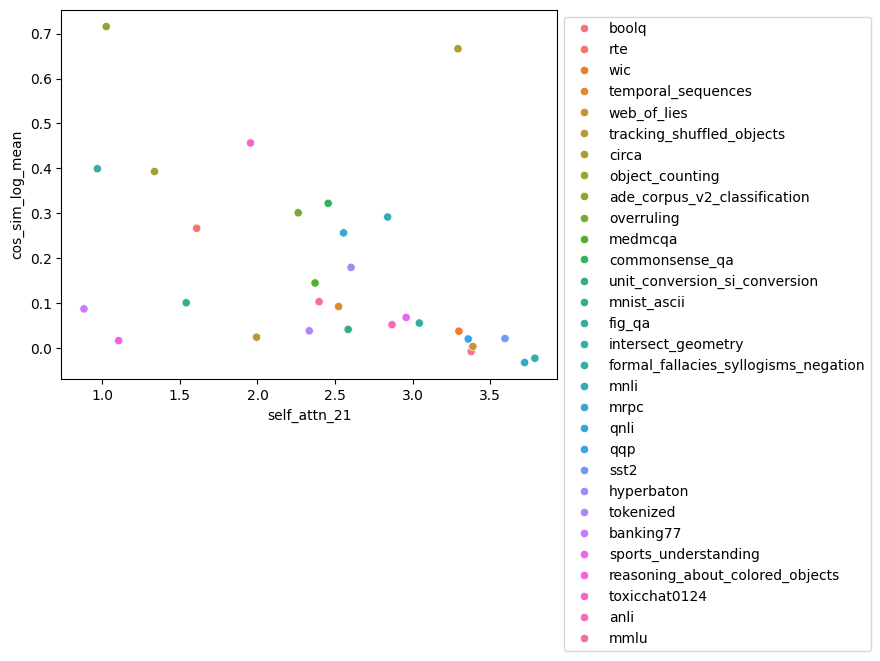

In [54]:
sns.scatterplot(tmp_fin_plot.reset_index().rename(columns={'index':'task'}), x='self_attn_21',y='cos_sim_log_mean',hue='task')
plt.legend(bbox_to_anchor=(1,1))

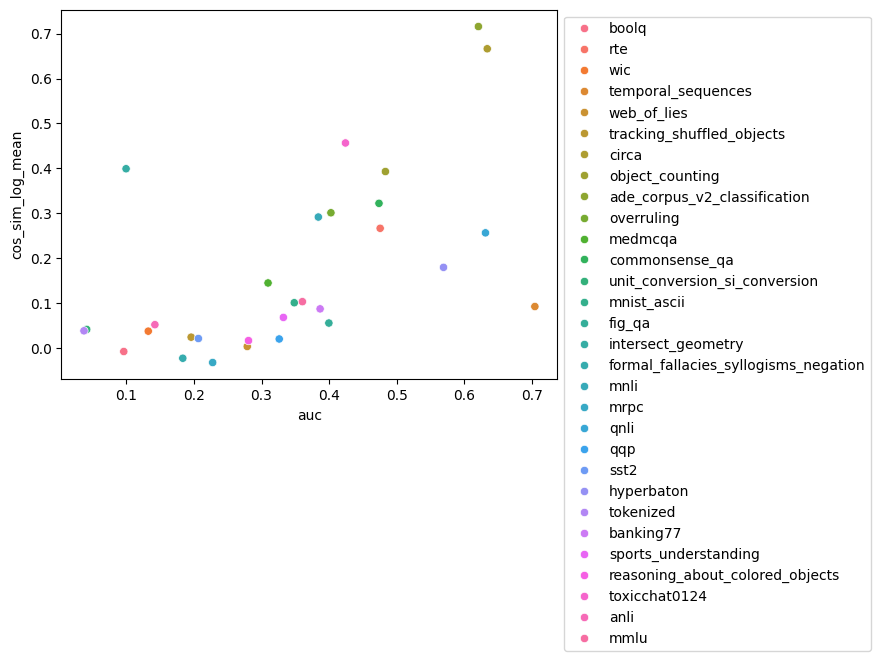

In [59]:
sns.scatterplot(tmp_fin_plot.reset_index().rename(columns={'index':'task'}), x='auc',y='cos_sim_log_mean',hue='task')
plt.legend(bbox_to_anchor=(1,1))

In [61]:
tmp_fin.to_json("tmp_db_index_conf0.json", orient='index', indent=4)
# tmp_db_index

In [62]:
with open("tmp_db_index_avg.json", "r") as f:
    saved = json.load(f)
tmp_avgd = pd.DataFrame(saved).T
# tmp_to_save = pd.concat([tmp_fin , tmp_saved])
# tmp_to_save.to_json("tmp_db_index_avg.json", orient='index', indent=4)

In [69]:
tmp_avgd.corr('spearman')[['cos_sim_mean','cos_sim_log_mean']].sort_values('cos_sim_mean').head(10)

,cos_sim_mean,cos_sim_log_mean
self_attn_13,-0.259113,-0.263547
self_attn_23,-0.253695,-0.250739
self_attn_21,-0.245813,-0.248768
mlp_0,-0.243842,-0.242857
self_attn_15,-0.241379,-0.240887
self_attn_30,-0.239409,-0.241379
self_attn_24,-0.238916,-0.236453
self_attn_22,-0.238424,-0.237438
self_attn_18,-0.237438,-0.236946
self_attn_4,-0.234483,-0.234975


Text(0.5, 1.0, 'Correlation -0.26354679802955666')

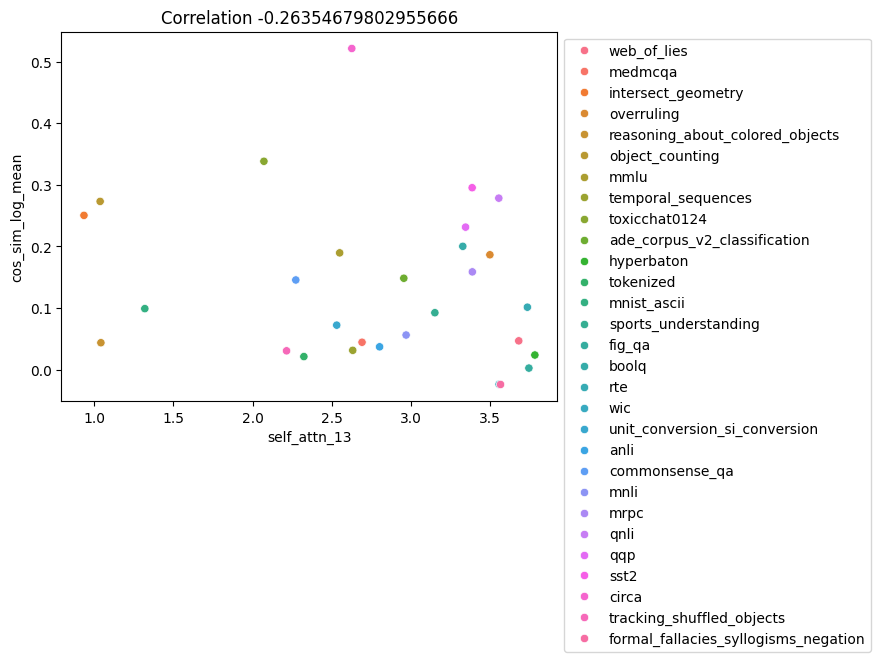

In [74]:
sns.scatterplot(tmp_avgd.reset_index().rename(columns={'index':'task'}), x='self_attn_13',y='cos_sim_log_mean',hue='task')
plt.legend(bbox_to_anchor=(1,1))
c = tmp_avgd.corr('spearman').loc['self_attn_13','cos_sim_log_mean']
plt.title(f"Correlation {c}")

Text(0.5, 1.0, 'Correlation -0.578642936596218')

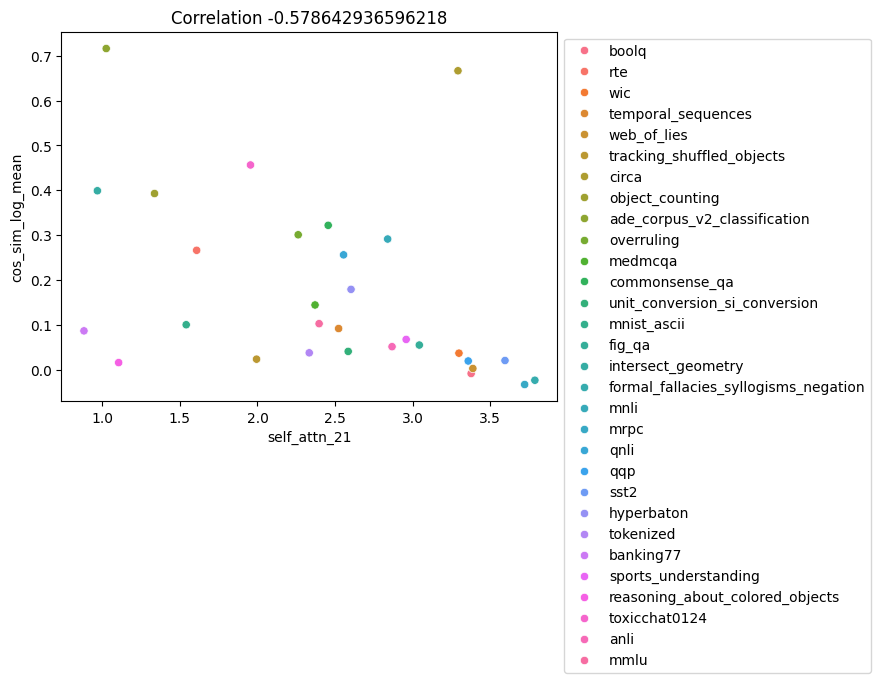

In [72]:
sns.scatterplot(tmp_fin_plot.reset_index().rename(columns={'index':'task'}), x='self_attn_21',y='cos_sim_log_mean',hue='task')
plt.legend(bbox_to_anchor=(1,1))
c = tmp_fin_plot.corr('spearman').loc['self_attn_21','cos_sim_log_mean']
plt.title(f"Correlation {c}")

In [46]:
gc.collect()
torch.cuda.empty_cache()
!nvidia-smi

Thu May  1 03:21:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.135                Driver Version: 550.135        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:98:00.0 Off |                  Off |
| 30%   22C    P8              7W /  300W |   22488MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [106]:
db_tmp = pd.DataFrame(task_dbindex['circa']).T

In [107]:
db_tmp['circa'] = db_tmp.mean(axis=1)

In [109]:
db_tmp[['circa']].T

,self_attn_0,mlp_0,self_attn_1,mlp_1,self_attn_2,mlp_2,self_attn_3,mlp_3,self_attn_4,mlp_4,...,self_attn_27,mlp_27,self_attn_28,mlp_28,self_attn_29,mlp_29,self_attn_30,mlp_30,self_attn_31,mlp_31
circa,3.398579,3.347949,3.458937,3.382278,3.466703,3.38931,3.524707,3.411881,3.478726,3.418918,...,3.679269,3.452269,3.455688,3.416406,3.446941,3.449822,3.435557,3.450227,3.486508,3.444622


## Old res

In [51]:
for i in range(4):
    print(task_activations[module][i].shape)

torch.Size([32, 213, 4096])
torch.Size([32, 218, 4096])
torch.Size([32, 220, 4096])
torch.Size([32, 218, 4096])


In [ ]:
[i.to(torch.float32) for i in task_activations[module]]

In [48]:
len(task_activations['self_attn_0'])

4

In [9]:
data = model_cls.get_data(tokenizer=tokenizer, max_seq_len=2048, subset_sample_path=False)

Map: 100%|██████████| 1444/1444 [00:00<00:00, 5318.52 examples/s]


(pre-filtering) Data train size : 2500 Validation: 500 Test: 1444


Filter: 100%|██████████| 1444/1444 [00:00<00:00, 8924.95 examples/s]

Data train size : 2500 Validation: 500 Test: 1444


In [10]:
# load cosine information
with open("../results/subsets/conf_decile_0_by_task.json", "r") as f:
    low_conf = json.load(f)
df_cos = load_cosine_stats(path="../results/per_sample_result/cosine_similarity_metrics_32_v2.json")
df_cos_low = load_cosine_stats(path="../results/per_sample_result/cosine_similarity_metrics_32_v2_conf_dec0.json")

In [19]:
avg_batch = batch_sample('train', np.arange(0,32))
lowconf_batch = batch_sample('train', low_conf['object_counting']['example_num'][:32])

In [21]:
print(avg_batch['input_ids'].shape)
print(lowconf_batch['input_ids'].shape)

torch.Size([32, 118])
torch.Size([32, 122])


In [25]:
df_cos[(df_cos['task']=='object_counting') & (df_cos['example_num'].isin(np.arange(0,32)))]['cos_sim'].values

array([ 0.17579801,  0.22814316, -0.00081775,  0.2090808 , -0.27404065,
        0.31180604,  0.25044187,  0.1046361 , -0.03395341,  0.23781151,
        0.08787564,  0.23261904,  0.26370259,  0.31335375,  0.21045881,
        0.27819292,  0.2465729 ,  0.16560464,  0.0965843 , -0.15121106,
        0.28030586,  0.29490688,  0.29520091,  0.24632889,  0.2521027 ,
        0.11352953,  0.27228178,  0.1488023 ,  0.2794681 ,  0.16621672,
        0.10405113,  0.18927092])

In [26]:
# def get_activation(batch):
    
#     activations = {}
    
#     with torch.no_grad():
#         _ = model(**batch)

#     return activations

In [35]:
with torch.no_grad():
    _ = model(**avg_batch)

In [ ]:
tsne = TSNE(n_components=2, perplexity=5)

In [47]:
mlp_layer_num = 32
batch_size = 32
avg_samples = {}
for i in range(mlp_layer_num):
    sample = activations[f'mlp_{i}'].reshape(batch_size, -1).to(torch.float16)
    reduced = tsne.fit_transform(sample)
    avg_samples[i] = reduced

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

In [48]:
avg_samples[0][:,0]

array([ -66.72384 ,  -43.186398, -134.77563 ,   86.84594 , -154.01747 ,
        104.896385,   36.887886,  -54.45087 ,  -44.047558, -143.3761  ,
        871.51306 ,  -68.57257 ,    8.097877,  115.32336 ,  -79.20048 ,
         14.252692,   31.759247,  103.883446,  -36.34102 ,  -67.28152 ,
        -31.033125,  134.62804 ,   71.08412 , -261.50165 ,  -25.277592,
        -23.087296,  115.09139 ,  127.65898 ,   15.438111,   50.328472,
         -4.294725, -116.611755], dtype=float32)

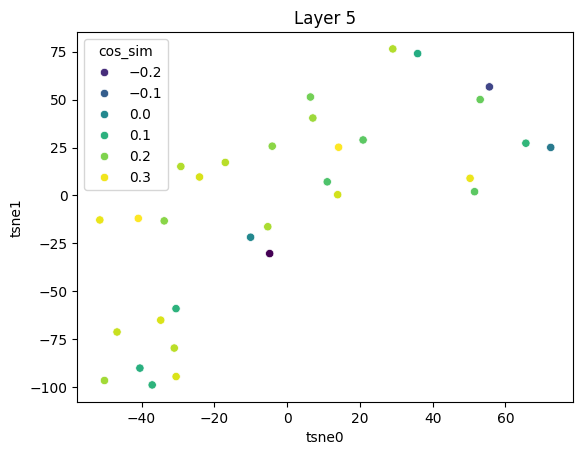

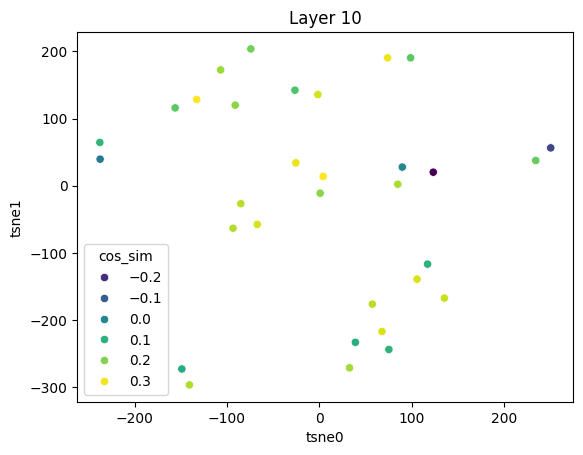

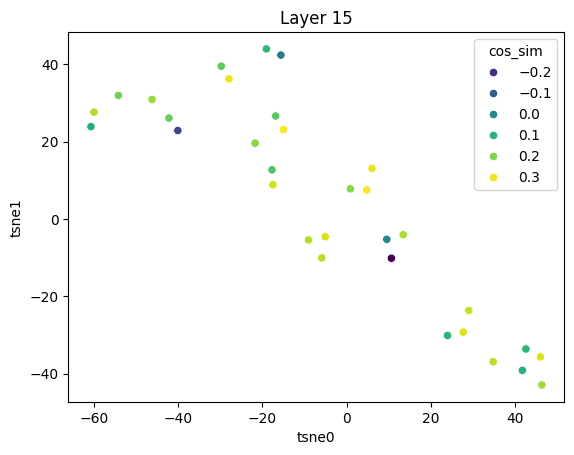

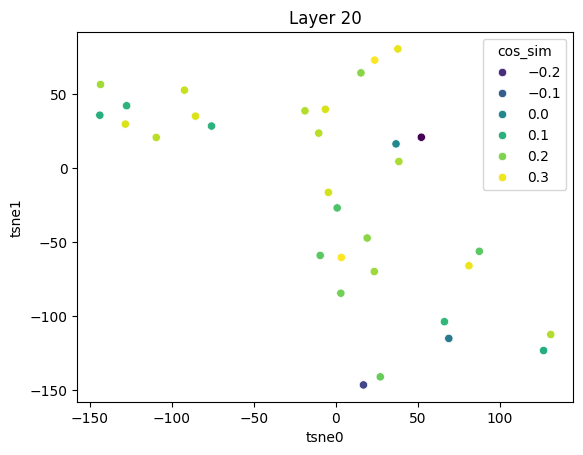

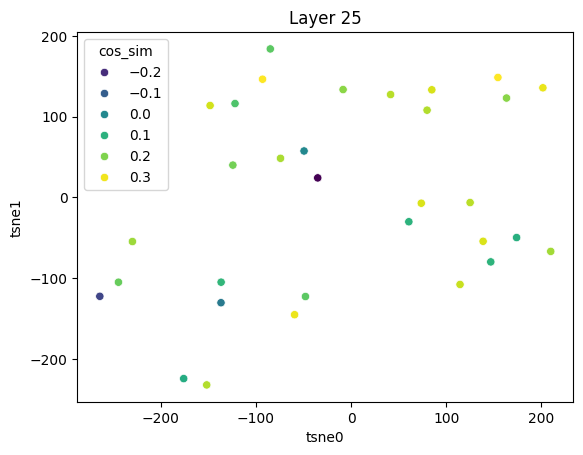

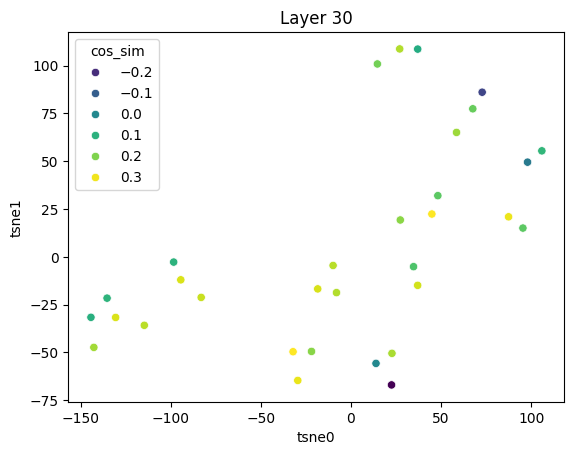

In [49]:
cos_values = df_cos[df_cos['task']=='object_counting'][:32]['cos_sim'].values
for i in [5,10,15,20,25,30]:
    
    df_samp = pd.DataFrame({"tsne0": avg_samples[i][:,0],
                  "tsne1": avg_samples[i][:,1],
                  "cos_sim": cos_values
    })
    
    sns.scatterplot(df_samp, x='tsne0', y='tsne1', hue='cos_sim', 
                    palette=sns.color_palette("viridis", as_cmap=True))
    plt.title(f"Layer {i}")
    plt.show()

## Low confidence samples

In [44]:
with torch.no_grad():
    _ = model(**lowconf_batch)

In [45]:
mlp_layer_num = 32
batch_size = 32
lowconf_samples = {}
for i in range(mlp_layer_num):
    sample = activations[f'mlp_{i}'].reshape(batch_size, -1).to(torch.float16)
    reduced = tsne.fit_transform(sample)
    lowconf_samples[i] = reduced

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

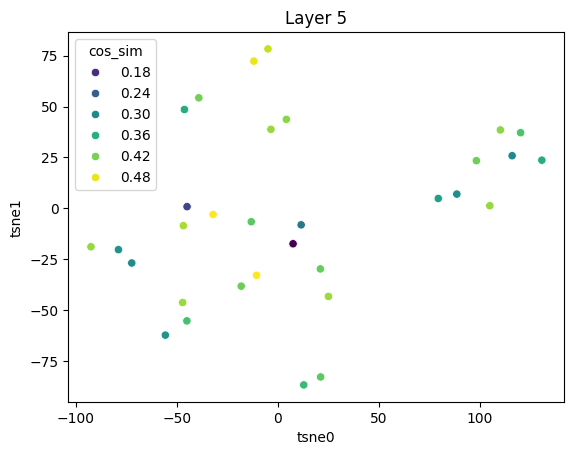

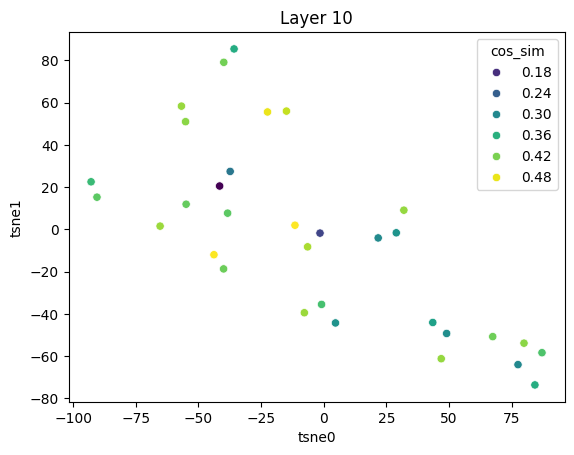

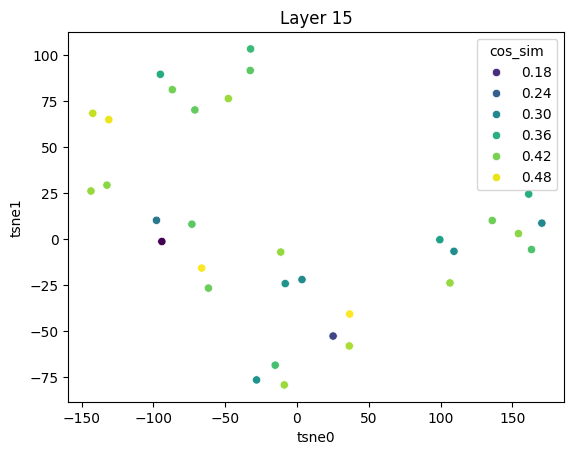

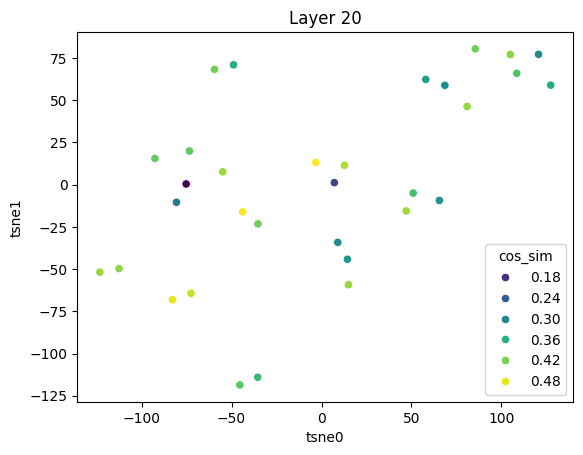

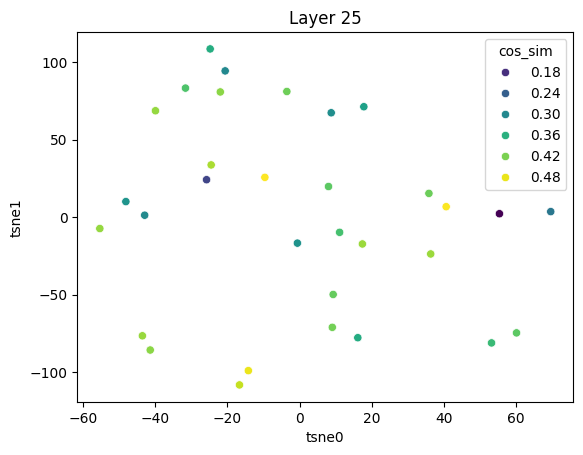

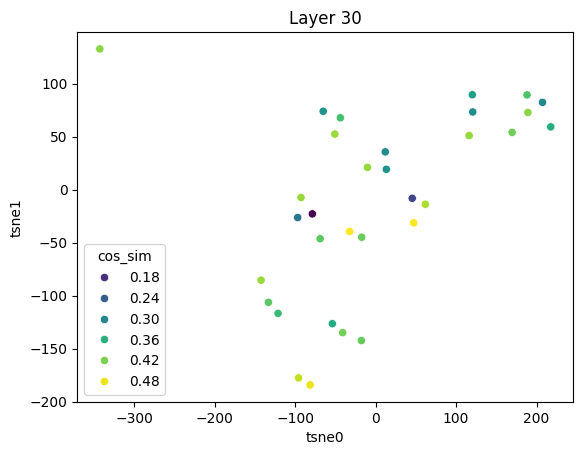

In [46]:
cos_values = df_cos_low[df_cos_low['task']=='object_counting'][:32]['cos_sim'].values
for i in [5,10,15,20,25,30]:
    
    df_samp = pd.DataFrame({"tsne0": lowconf_samples[i][:,0],
                  "tsne1": lowconf_samples[i][:,1],
                  "cos_sim": cos_values
    })
    
    sns.scatterplot(df_samp, x='tsne0', y='tsne1', hue='cos_sim', 
                    palette=sns.color_palette("viridis", as_cmap=True))
    plt.title(f"Layer {i}")
    plt.show()

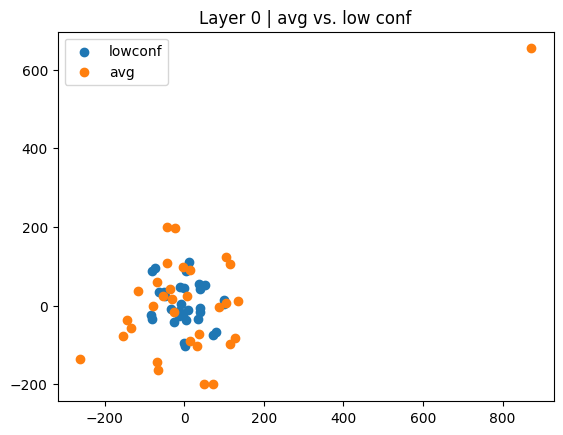

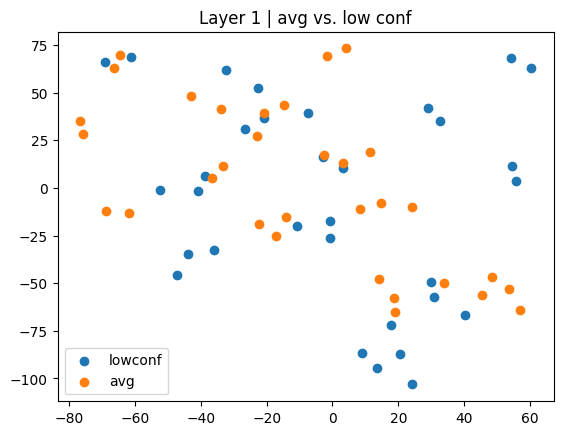

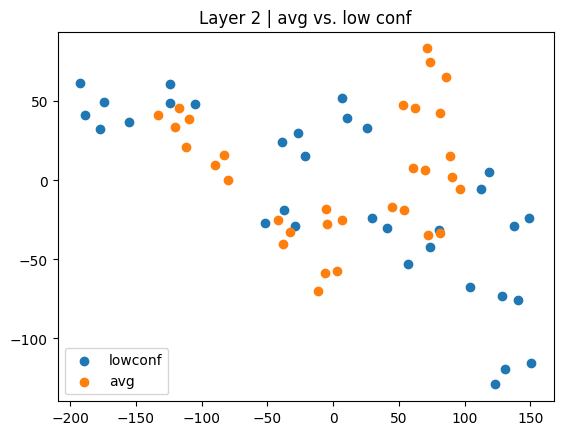

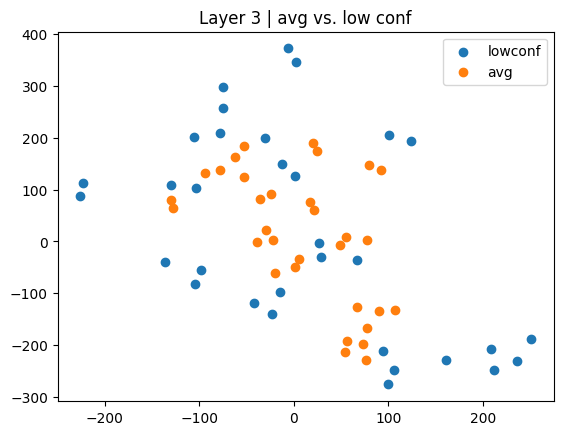

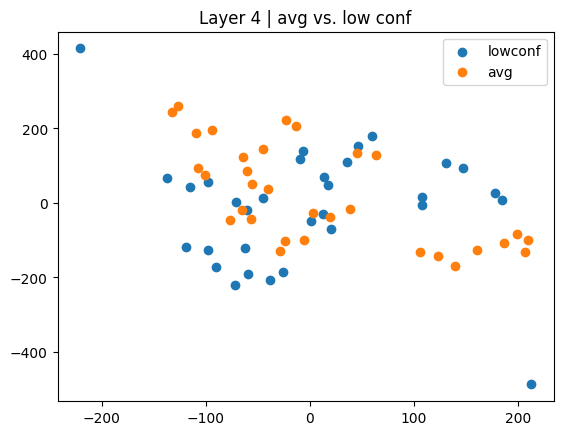

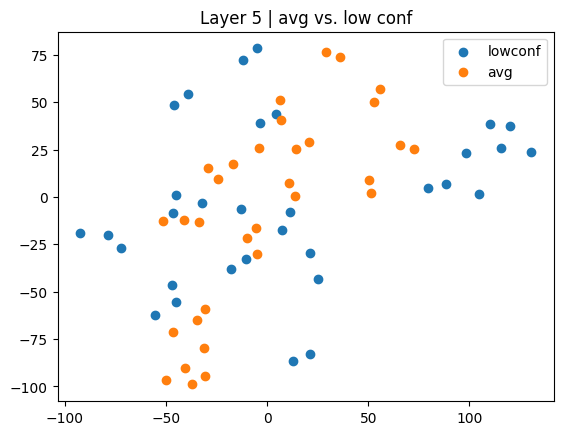

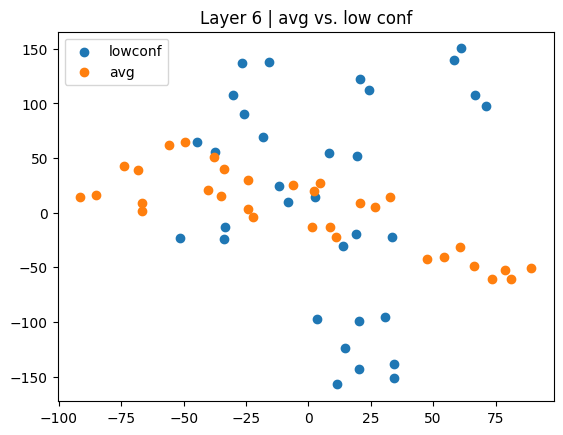

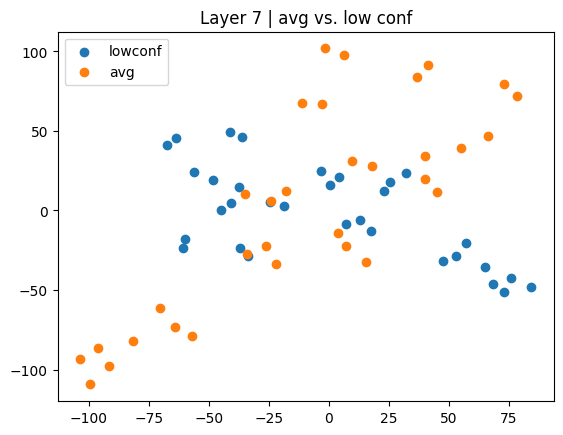

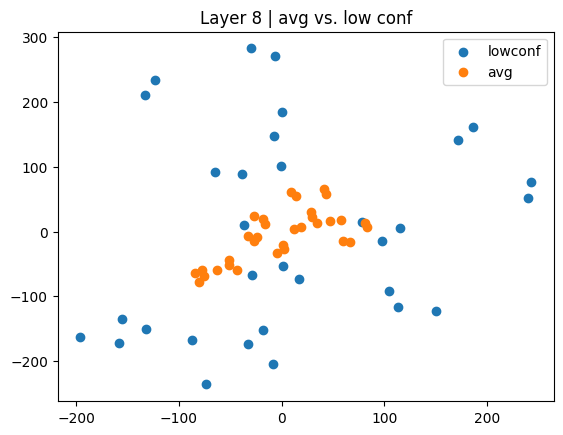

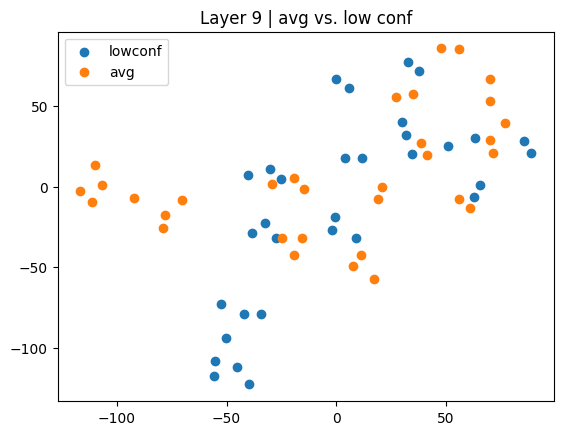

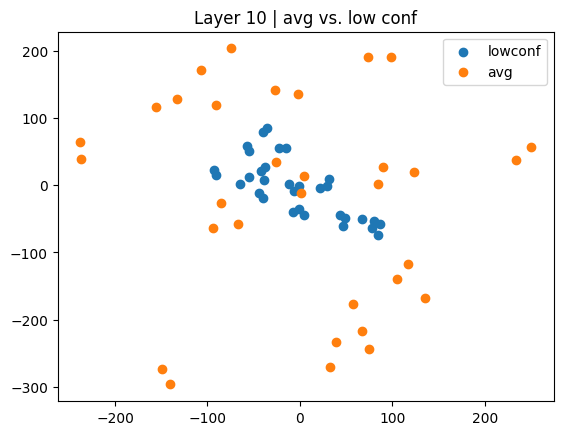

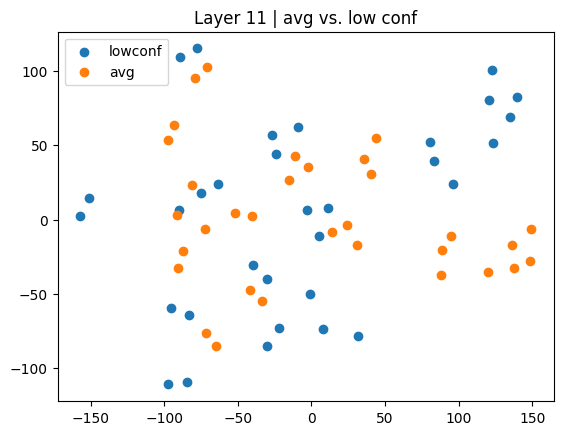

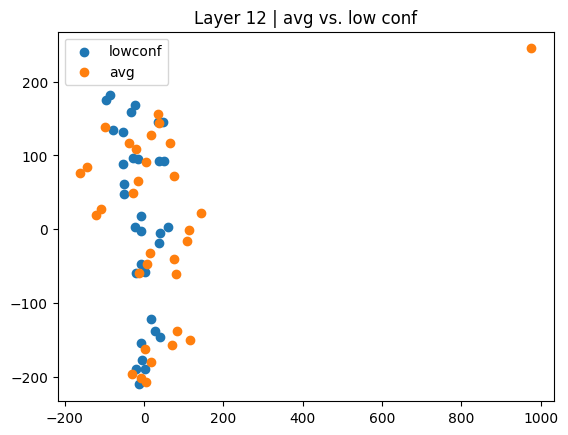

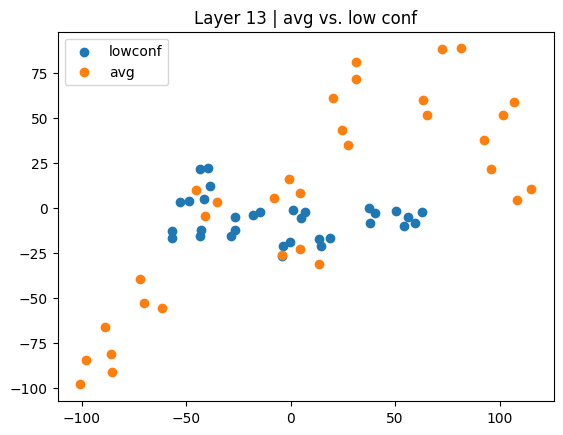

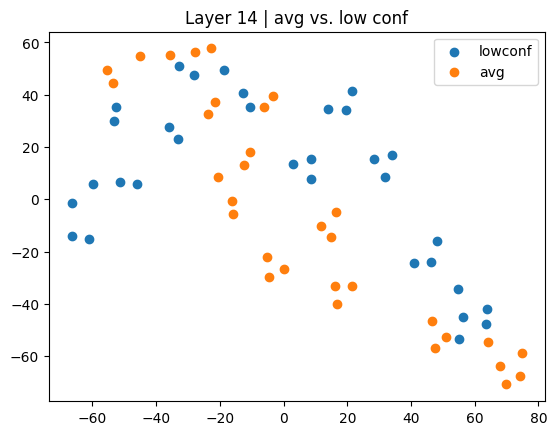

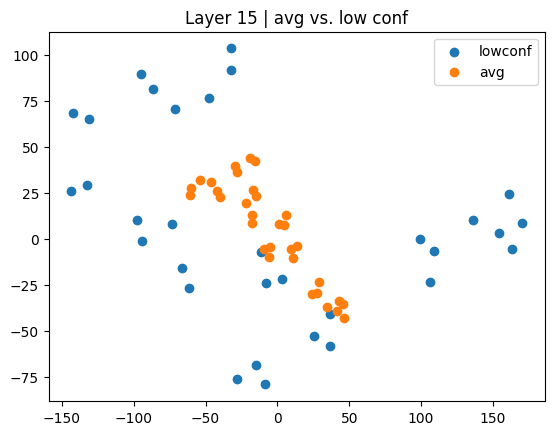

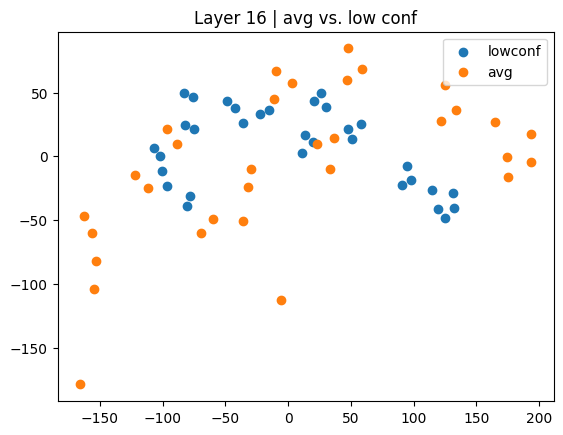

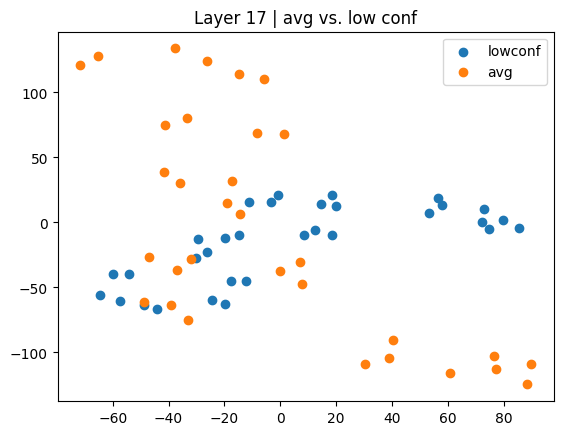

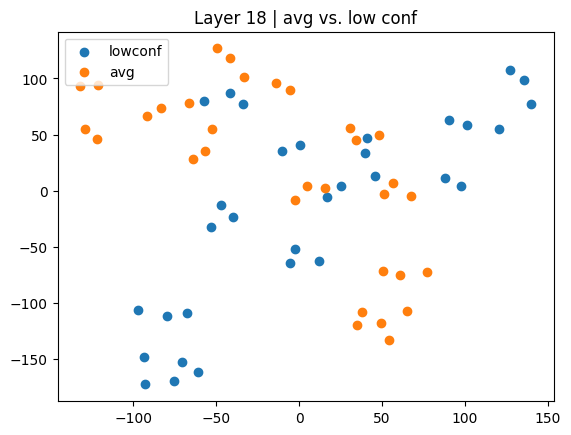

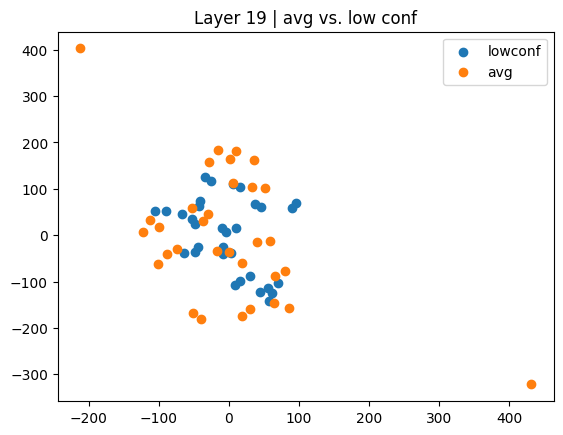

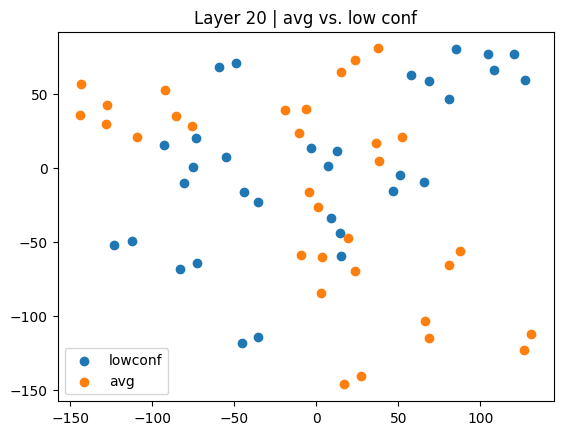

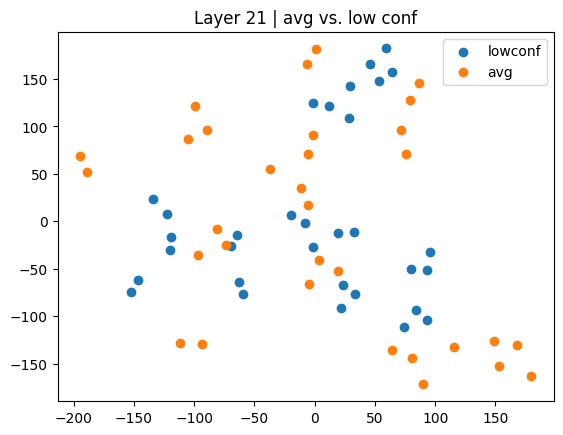

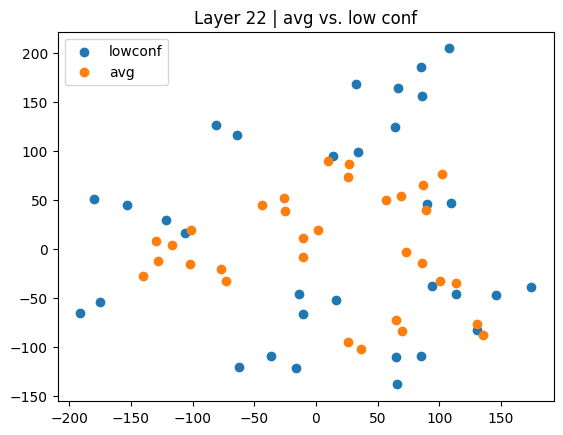

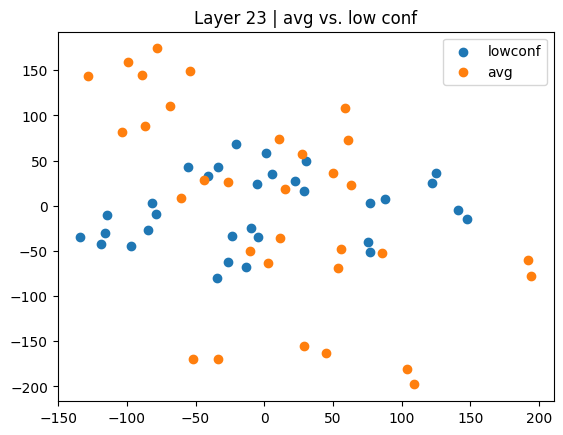

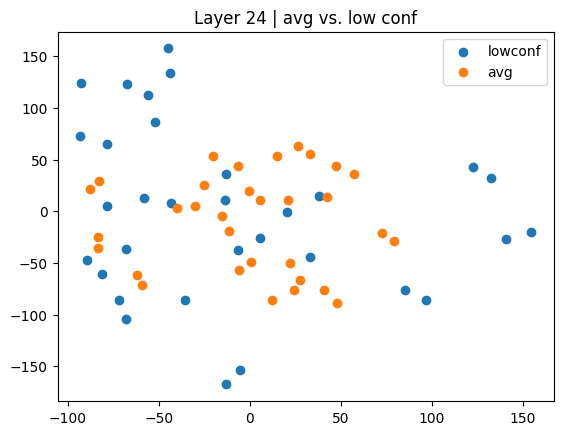

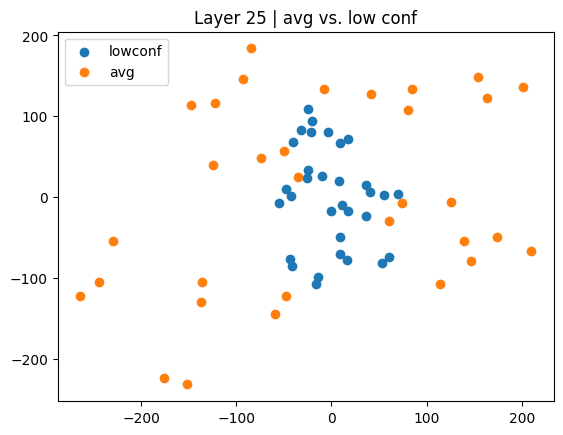

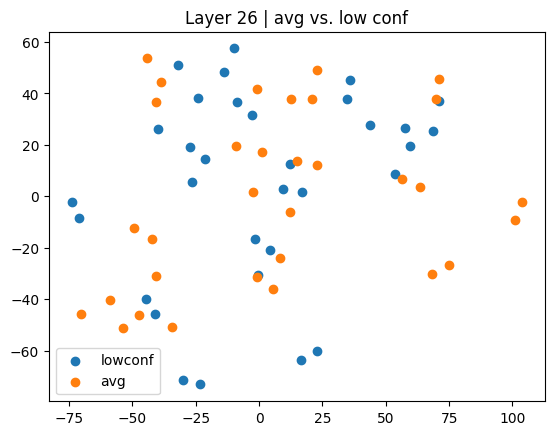

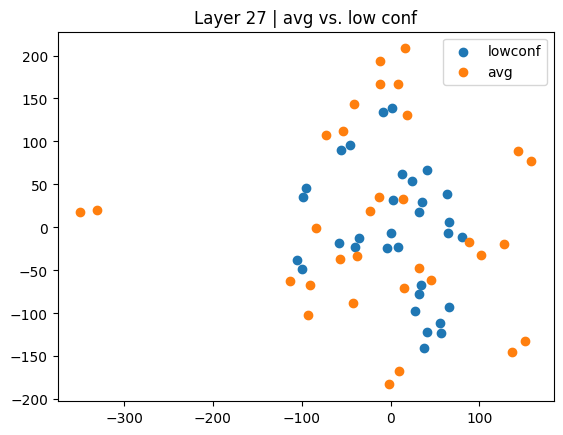

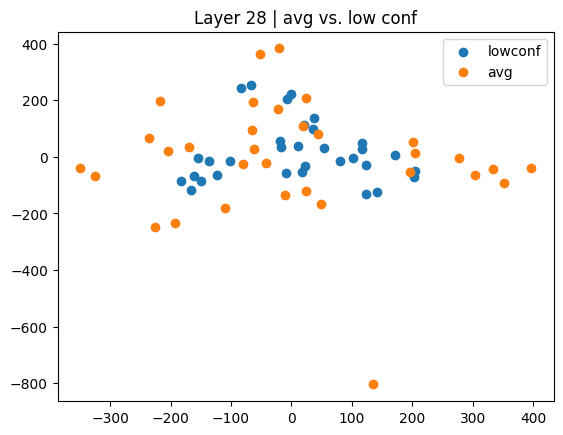

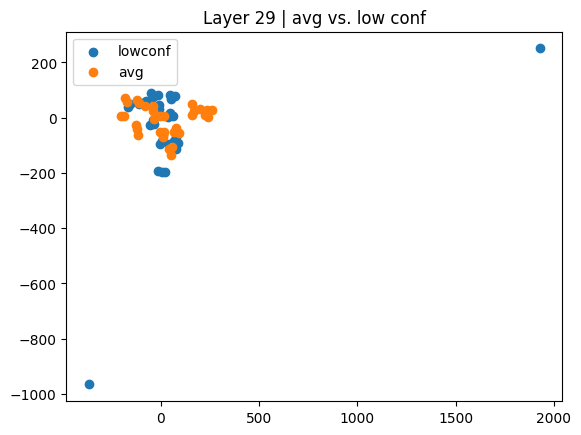

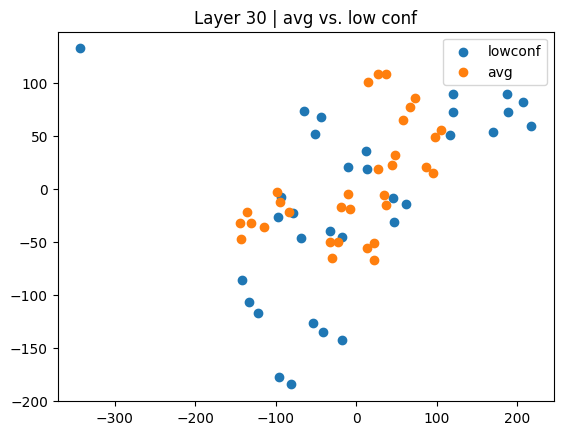

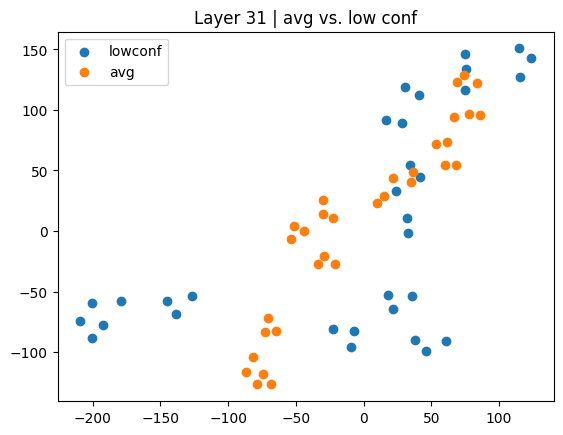

In [51]:
for i in np.arange(32):
    plt.scatter(lowconf_samples[i][:, 0], lowconf_samples[i][:, 1], label = 'lowconf')
    plt.scatter(avg_samples[i][:, 0], avg_samples[i][:, 1], label = 'avg')
    plt.title(f"Layer {i} | avg vs. low conf")
    plt.legend()
    plt.show()

## DB index analysis

In [52]:
from sklearn.metrics import davies_bouldin_score

In [55]:
df_proba = load_proba_stats(path="../results/per_sample_result/model_proba_per_sample_2500_v2.json")

In [ ]:
# df_proba['target_str'] = df_proba.apply(lambda x: " ".join([str(i) for i in x['target']]), axis=1)

In [92]:
df_proba['target_first'] = df_proba['target'].str[0]

In [83]:
sample_mlp0 = activations['mlp_0'].reshape(32,-1).to(torch.float32)

In [84]:
sample_mlp0.shape

torch.Size([32, 499712])

In [98]:
labels = df_proba[(df_proba['task']=='object_counting') &
                (df_proba['example_num'].isin(np.arange(32)))]['target_first'].values

In [100]:
len(labels)

32

In [121]:
with torch.no_grad():
    _ = model(**avg_batch)

mlp_scores = []
attn_scores = []
for layer in np.arange(32):
    sample_mlp = activations[f'mlp_{layer}'].reshape(32,-1).to(torch.float32)
    score_mlp = davies_bouldin_score(sample_mlp, labels)
    scores_mlp.append(score_mlp)
    
    sample_attn = activations[f'self_attn_{layer}'].reshape(32,-1).to(torch.float32)
    score_attn = davies_bouldin_score(sample_attn, labels)
    scores_attn.append(score_attn)
    print(f"Layer {layer} mlp score {score_mlp}, attn {score_attn}")

AttributeError: 'tuple' object has no attribute 'detach'

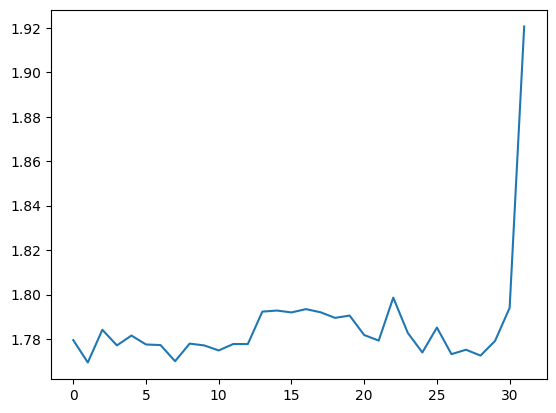

In [107]:
plt.plot(np.arange(32), scores)